In [15]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import plotly.express as px
import nltk
from wordcloud import WordCloud , STOPWORDS
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
import re, string ,unicodedata
from sklearn.metrics import classification_report, confusion_matrix,accuracy_score, f1_score
from string import punctuation
from nltk import pos_tag
import re
import warnings
warnings.filterwarnings('ignore')

In [7]:
%%time
df=pd.read_csv(r'IMDB-Dataset.csv',encoding='utf-8', engine='python')

CPU times: total: 5.34 s
Wall time: 5.43 s


In [8]:
#DATA CLEANING AND PREPROCESSING
import nltk
# Download the 'stopwords' resource
nltk.download('stopwords') 

from nltk.corpus import stopwords
stop_words = stopwords.words('english')
new_stopwords = ['movie', 'one', 'film', 'would', 'shall', 'could', 'might']
stop_words.extend(new_stopwords)
stop_words.remove("not") #for sarcasm
stop_words = set(stop_words)

# stop_words is now a set containing the modified list of English stopwords

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\91969\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [9]:
import re 


## Special Character & URL Removal
def remove_special_character(content):
    """Removes all non-alphanumeric characters (except whitespace) and URLs."""
    # 1. Remove URLs first
    content = re.sub(r'http\S+|www\S+|https\S+', '', content, flags=re.MULTILINE)
    # 2. Replace all non-word characters (excluding spaces and single quote) with a space
    content = re.sub(r'[^A-Za-z0-9\s\']', ' ', content) 
    return content.strip()

## Contraction Expansion
def contraction_expansion(content):
    """Expands common English contractions."""
    # Handle specific 'not' contractions first
    content = re.sub(r"won\'t", "will not", content) 
    content = re.sub(r"can\'t", "can not", content)
    content = re.sub(r"don\'t", "do not", content)
    content = re.sub(r"shouldn\'t", "should not", content)
    content = re.sub(r"needn\'t", "need not", content)
    content = re.sub(r"hasn\'t", "has not", content)
    content = re.sub(r"haven\'t", "have not", content)
    content = re.sub(r"weren\'t", "were not", content)
    content = re.sub(r"mightn\'t", "might not", content)
    content = re.sub(r"didn\'t", "did not", content)
    
    # Handle general 'not' contractions
    content = re.sub(r"n\'t", " not", content) 
    
    # Handle other general contractions
    content = re.sub(r"\'re", " are", content)
    content = re.sub(r"\'s", " is", content)
    content = re.sub(r"\'d", " would", content)
    content = re.sub(r"\'ll", " will", content)
    content = re.sub(r"\'ve", " have", content)
    content = re.sub(r"\'m", " am", content)
    
    return content

## Stopword Removal
def remove_stopwords(content):
    """Removes stopwords and non-alphabetic tokens."""
    clean_data=[]
    for i in content.split():
        token = i.strip().lower()
        if token not in stop_words and token.isalpha():
            clean_data.append(token)
    return " ".join(clean_data)

## Data Preprocessing Pipeline
def data_cleaning(content):
    """The main text cleaning pipeline."""
    # 1. Expand contractions (e.g., 'don't' -> 'do not')
    content = contraction_expansion(content)
    # 2. Remove special characters and URLs (and normalize to spaces)
    content = remove_special_character(content)
    # 3. Remove stopwords and non-alphabetic tokens
    content = remove_stopwords(content)
    
    return content

In [10]:
%%time 
# Data Cleaning: 
df['Reviews'] = df['Reviews'].apply(data_cleaning)

print(df[['Reviews']].head(5))

                                             Reviews
0  disclaimer watched conditional agreement see f...
1  writing hopes gets put previous review anyone ...
2  really write scathing review turd sandwich ins...
3  saw previous spoof movies two horrible gentlem...
4  saw day early free still feel like got ripped ...
CPU times: total: 18.9 s
Wall time: 19.2 s


In [11]:
df.isna().sum()


Ratings      0
Reviews      0
Movies      25
Resenhas     0
dtype: int64

In [12]:
print("unique movie name is : %s" % df.Movies.nunique())
print("No of rating is : %s" % df.Ratings.count())

unique movie name is : 14206
No of rating is : 150000


In [ ]:
#EXPLOARATORY DATA ANALYSIS

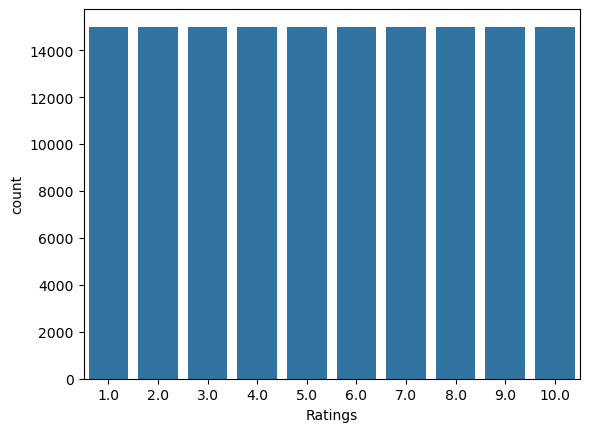

Ratings
1.0     15000
2.0     15000
4.0     15000
3.0     15000
5.0     15000
6.0     15000
8.0     15000
7.0     15000
10.0    15000
9.0     15000
Name: count, dtype: int64


In [13]:
#check for class imbalance - Binary classification
sns.countplot(x=df['Ratings'])
plt.show()
print(df['Ratings'].value_counts())


In [14]:
!pip install wordcloud





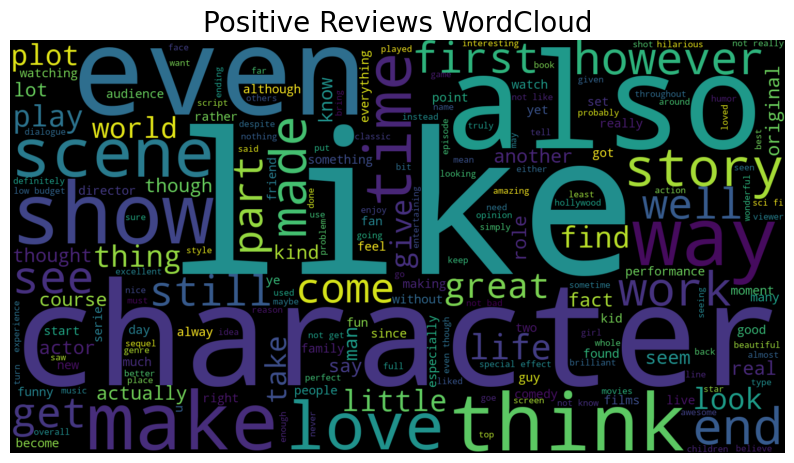

CPU times: total: 43.1 s
Wall time: 44.3 s


In [19]:
%%time 

# Define positive and negative text subsets
sentences = df['Reviews']

# 1. POSITIVE Reviews (e.g., Ratings 7 and above)
pos = ' '.join(map(str, sentences[df['Ratings'] >= 7]))

# 2. NEGATIVE Reviews (e.g., Ratings 1, 2, 3 - less than 4)
neg = ' '.join(map(str, sentences[df['Ratings'] < 4]))


# 3. Create WordCloud (Correcting the variable name pos-wordcloud to pos_wordcloud)
pos_wordcloud = WordCloud(
    width=1500, 
    height=800, 
    background_color='black', 
    stopwords=stop_words,
    min_font_size=15
).generate(pos)

# 4. Plot the WordCloud
plt.figure(figsize=(10,10))
plt.imshow(pos_wordcloud, interpolation='bilinear')
plt.title('Positive Reviews WordCloud', fontsize=20)
plt.axis('off')
plt.show()

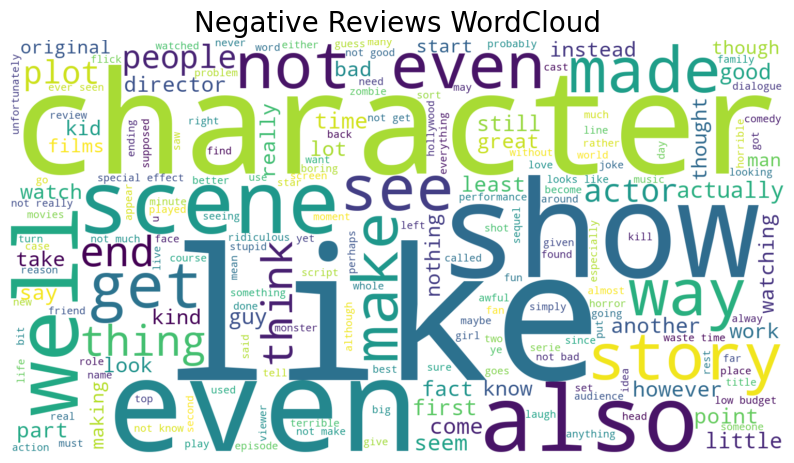

In [20]:
neg_wordcloud = WordCloud(
    width=1500, 
    height=800, 
    background_color='white', 
    stopwords=stop_words, 
    min_font_size=15
).generate(neg)

plt.figure(figsize=(10,10))
plt.imshow(neg_wordcloud, interpolation='bilinear')
plt.title('Negative Reviews WordCloud', fontsize=20)
plt.axis('off')
plt.show()

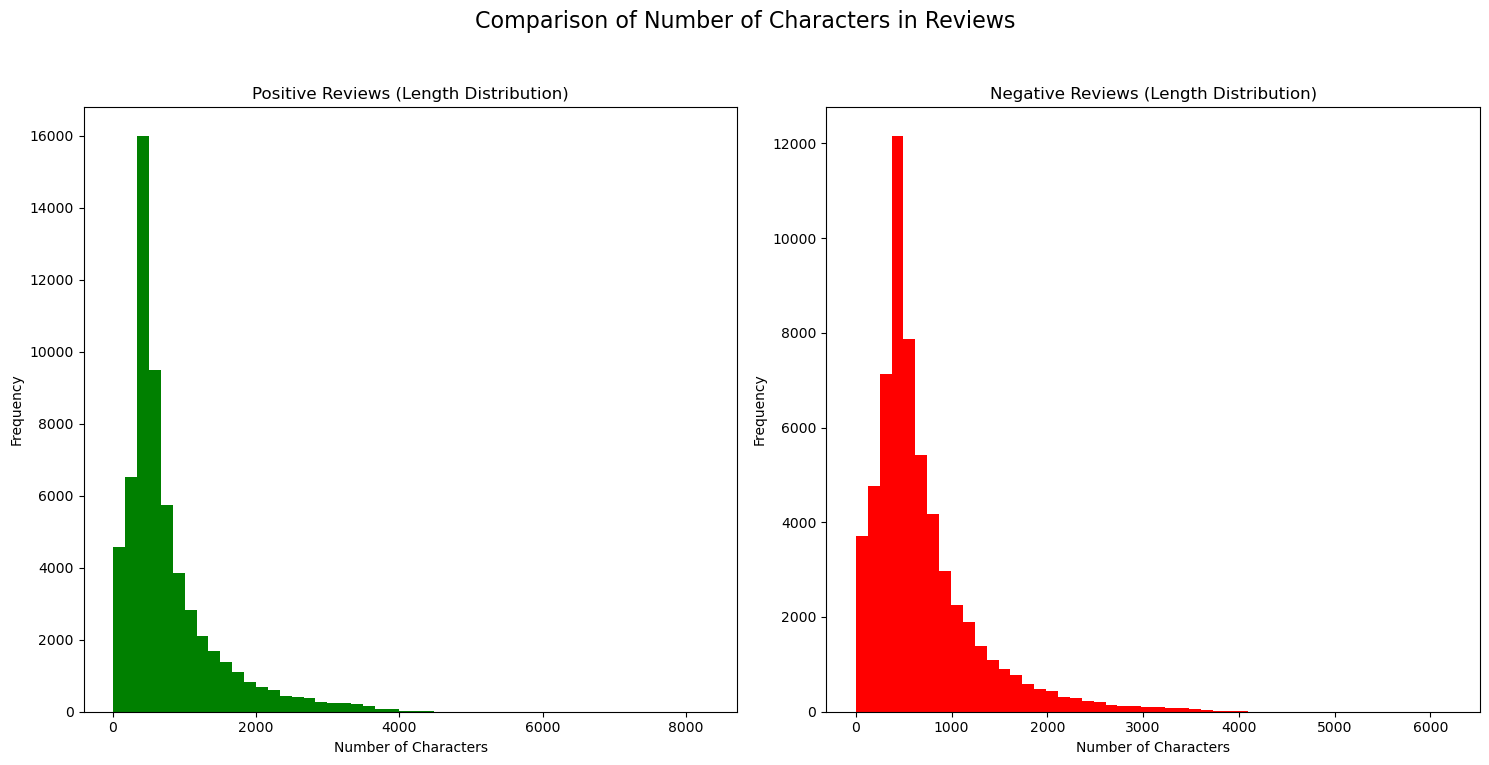

CPU times: total: 500 ms
Wall time: 799 ms


In [22]:
%%time 
# Basic statistics of review data
# Create two subplots (1 row, 2 columns)
figure, (pos_ax, neg_ax) = plt.subplots(1, 2, figsize=(15, 8))

# --- Positive Review Lengths (Ratings >= 7) ---
len_pos_review = df[df['Ratings'] >= 7]['Reviews'].str.len()
pos_ax.hist(len_pos_review, color='green', bins=50) # Added bins for better visualization
pos_ax.set_title('Positive Reviews (Length Distribution)')
pos_ax.set_xlabel('Number of Characters')
pos_ax.set_ylabel('Frequency')

# --- Negative Review Lengths (Ratings <= 4) ---
len_neg_review = df[df['Ratings'] <= 4]['Reviews'].str.len()
# FIX: Plot on the 'neg_ax' using 'len_neg_review'
neg_ax.hist(len_neg_review, color='red', bins=50) 
neg_ax.set_title('Negative Reviews (Length Distribution)')
neg_ax.set_xlabel('Number of Characters')
neg_ax.set_ylabel('Frequency')

# Set the overall title
figure.suptitle('Comparison of Number of Characters in Reviews', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to fit suptitle
plt.show()

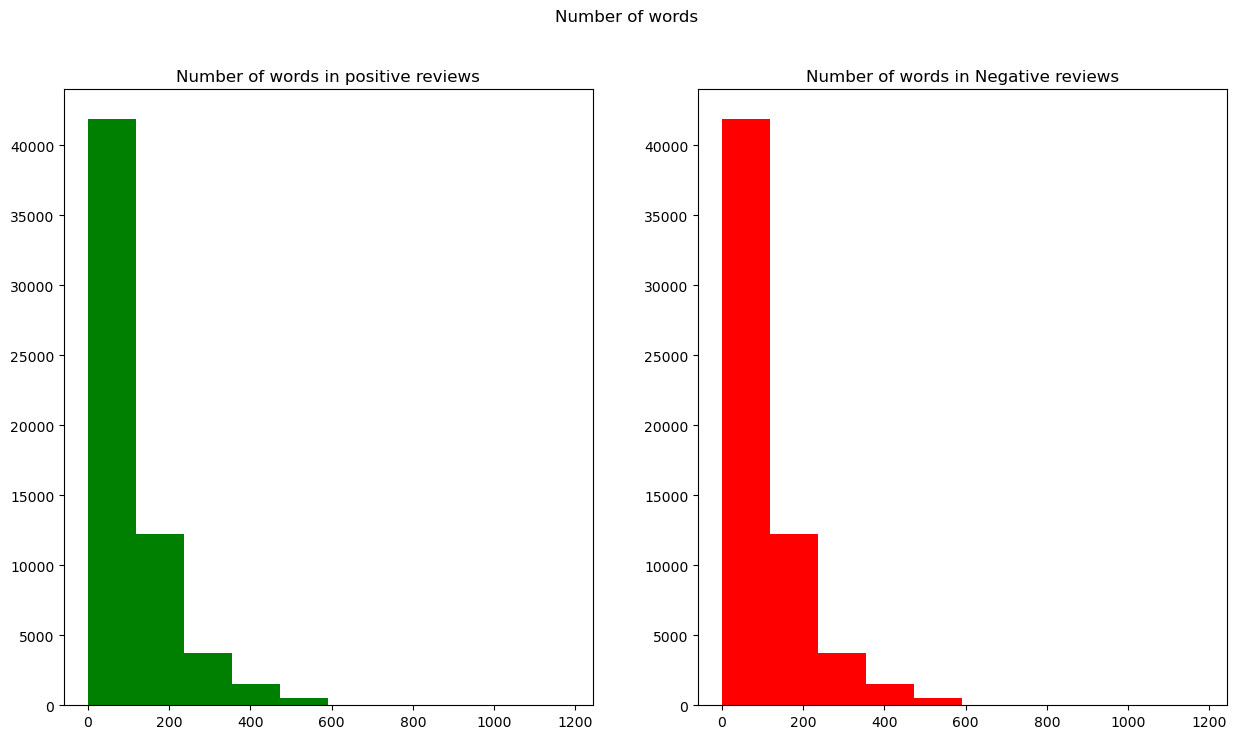

In [23]:
figure, (pos_ax, neg_ax) = plt.subplots(1, 2, figsize=(15, 8))
pos_word=df[df['Ratings'] >= 7]['Reviews'].str.split().map(lambda review: len(review))
pos_ax.hist(pos_word, color='green')
pos_ax.set_title('Number of words in positive reviews')
neg_word=df[df['Ratings'] >= 4]['Reviews'].str.split().map(lambda review: len(review))
neg_ax.hist(pos_word, color='red')
neg_ax.set_title('Number of words in Negative reviews')
figure.suptitle('Number of words')
plt.show()


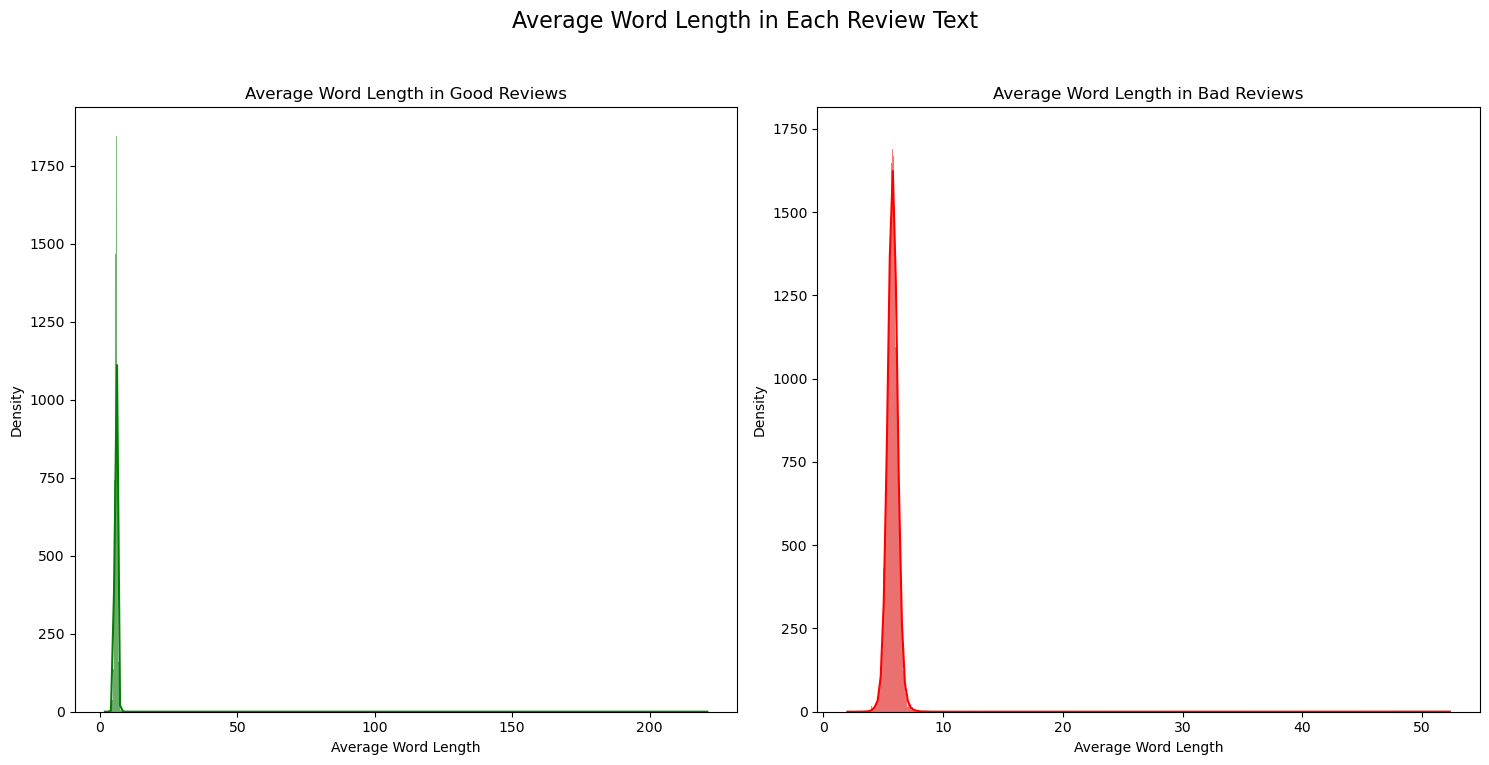

CPU times: total: 17.5 s
Wall time: 16.5 s


In [26]:
%%time 
# Average word length in a text

figure, (pos_ax, neg_ax) = plt.subplots(1, 2, figsize=(15, 8))

# --- Positive Review Word Length (Ratings >= 7) ---
pos_word = df[df['Ratings'] >= 7]['Reviews'].str.split().apply(lambda x: [len(i) for i in x])
# Calculate the mean word length for each review
pos_mean_len = pos_word.map(lambda x: np.mean(x))

# Plot on pos_ax (Fix: used pos_ax instead of ax1)
sns.histplot(pos_mean_len, ax=pos_ax, color='green', kde=True)
pos_ax.set_title('Average Word Length in Good Reviews')
pos_ax.set_xlabel('Average Word Length')
pos_ax.set_ylabel('Density')


# --- Negative Review Word Length (Ratings <= 4) ---
neg_word = df[df['Ratings'] <= 4]['Reviews'].str.split().apply(lambda x: [len(i) for i in x])
# Calculate the mean word length for each review
neg_mean_len = neg_word.map(lambda x: np.mean(x))

# Plot on neg_ax (Fix: used neg_ax instead of ax2)
sns.histplot(neg_mean_len, ax=neg_ax, color='red', kde=True)
neg_ax.set_title('Average Word Length in Bad Reviews')
neg_ax.set_xlabel('Average Word Length')
neg_ax.set_ylabel('Density')


# Set the overall title (Fix: used figure instead of fig)
figure.suptitle('Average Word Length in Each Review Text', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout
plt.show()

In [27]:
#Get important feature by using countvectorizer
def get_top_text_ngrams(corpus, n, g):
    vec = CountVectorizer(ngram_range=(g, g)).fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0) 
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq =sorted(words_freq, key = lambda x: x[1], reverse=True)
    return words_freq[:n]


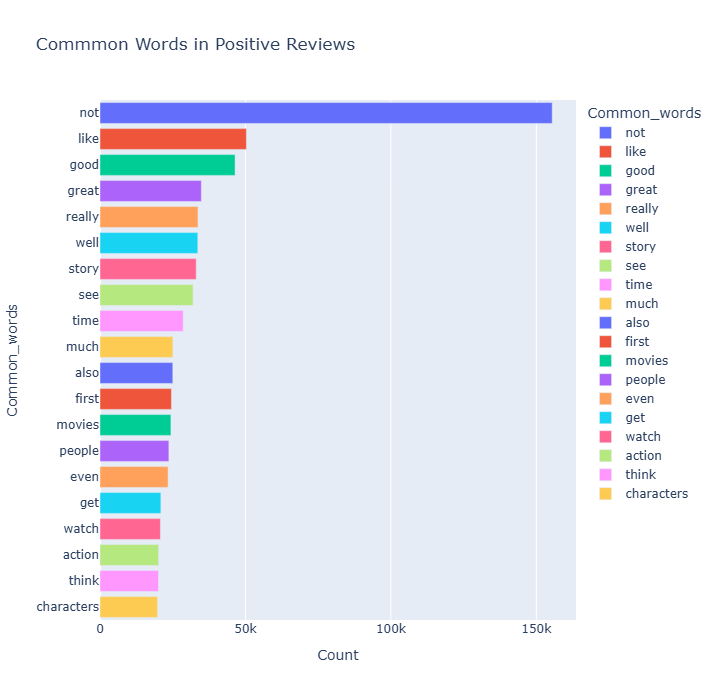

In [31]:
# Assuming your cleaned data is in the 'Reviews' column
from sklearn.feature_extraction.text import CountVectorizer
most_common_uni = get_top_text_ngrams(df['Reviews'][df['Ratings']>=7], 20, 1)

most_common_uni = dict(most_common_uni)
temp = pd.DataFrame(columns=["Common_words", 'Count'])
temp["Common_words"] = list(most_common_uni.keys())
temp["Count"] = list(most_common_uni.values())

fig = px.bar(
    temp, 
    x="Count", 
    y="Common_words", 
    title='Commmon Words in Positive Reviews', 
    orientation='h', 
    width=700, 
    height=700, 
    color='Common_words'
)
fig.show()

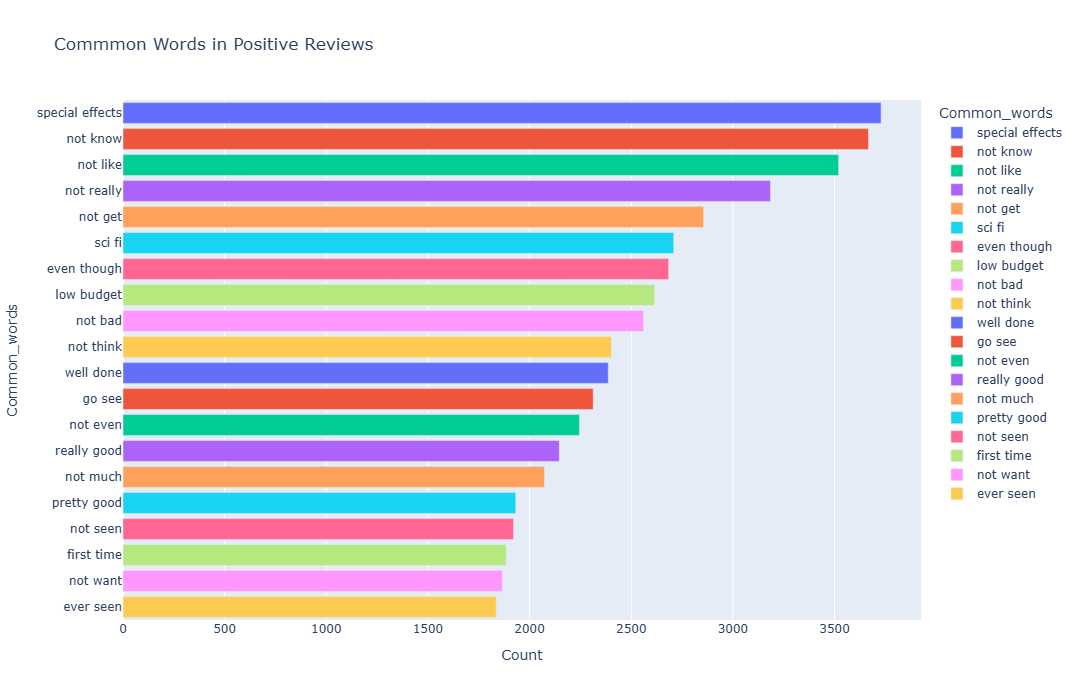

In [32]:
# Assuming your cleaned data is in the 'Reviews' column
#Bigrams - Two words
from sklearn.feature_extraction.text import CountVectorizer
most_common_uni = get_top_text_ngrams(df['Reviews'][df['Ratings']>=7], 20, 2)

most_common_uni = dict(most_common_uni)
temp = pd.DataFrame(columns=["Common_words", 'Count'])
temp["Common_words"] = list(most_common_uni.keys())
temp["Count"] = list(most_common_uni.values())

fig = px.bar(
    temp, 
    x="Count", 
    y="Common_words", 
    title='Commmon Words in Positive Reviews', 
    orientation='h', 
    width=700, 
    height=700, 
    color='Common_words'
)
fig.show()

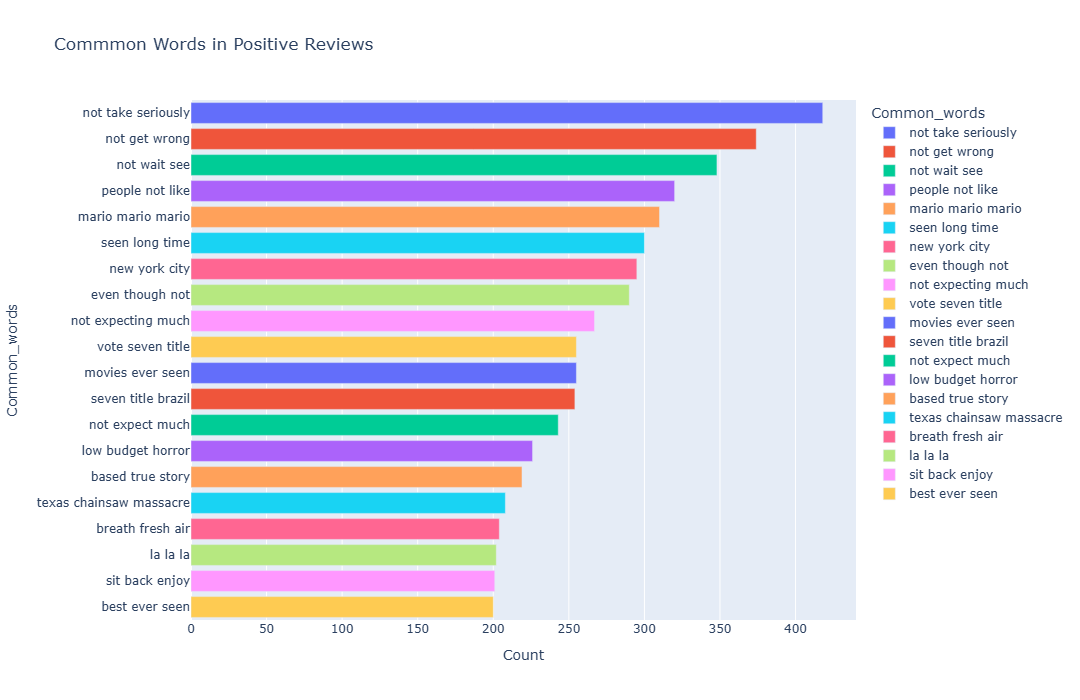

In [34]:
#Trigrams
# Assuming your cleaned data is in the 'Reviews' column
#Bigrams - Two words
from sklearn.feature_extraction.text import CountVectorizer
most_common_uni = get_top_text_ngrams(df['Reviews'][df['Ratings']>=7], 20, 3)

most_common_uni = dict(most_common_uni)
temp = pd.DataFrame(columns=["Common_words", 'Count'])
temp["Common_words"] = list(most_common_uni.keys())
temp["Count"] = list(most_common_uni.values())

fig = px.bar(
    temp, 
    x="Count", 
    y="Common_words", 
    title='Commmon Words in Positive Reviews', 
    orientation='h', 
    width=700, 
    height=700, 
    color='Common_words'
)
fig.show()

In [35]:
pd.options.display.max_colwidth = 1000
df[["Reviews","Ratings","Movies"]][(df['Ratings']>=7)&(df['Reviews'].str.contains("not like| not want| not big fan"))].head(30)


,Reviews,Ratings,Movies
90015,honest not watch initially bad reviews professional reviewers yesterday got dvd thought not watch least minutes really surprised enjoyed fist minutes decided watch entire honest blast not bad reviews suggest not know reviewers not like anyhow lets talk story story fine screenplay good dialogues situations okay laughed almost every gag saif role mental guy superb stole show character ram kapoor roles good felt ritesh not get excellent lines deliver got movies like masti dhamaal girls small roles nothing much wonder made serious actor like bipasha type anyhow feel sajid khan good job people watch reviewers not taste like humshakals better story gags compared sajid previous movies enjoy good laugh cheers,7.0,Humshakals
90041,stars bill oberst jr rich goteri written directed jason hull digress abit critiqued video vhs elves starred dan haggerty santa vs nazi xmas elves watched every christmas till tape broke krampus given us new viewing tradition next annual ritual not want spoilers santa krampus along demon actually well told script cop naughty list grew lots violence cool deaths oxymoron statement winter equals snow locale adds lots look makings cult build better poster maybe push great soundtrack,7.0,Krampus: The Christmas Devil
90042,way vampire begins around turn century england abraham van helsing rhett giles immortal assembled gang vampire slayers not scooby gang like buffy first minutes gang slaughtered van helsing decapitates dracula dracula gang left temporary chaos prince replace sebastien andreas beckett mistaken van helsing eligible member gang unfortunately left sebastien wife sebastien turned vampire van helsing earning bacon opening credits roll propelled present van helsing moved los angeles try jumpstart career naturally sebastien current gang guess kind chaos ensue first whoever sound mix dvd general matter looking another job pronto even raw sound bad adr done seems like case easily cleaned competent sound engineer turn music get rid horrendous echo scenes filmed large concrete room compensate actors whispering mumbling surround sound mix horrible stereo mix horrible even commentary track sounds like recorded large empty bathroom took least solid point screw equalizer crank system loud enough th...,7.0,Way of the Vampire
90058,rapsittie street kids believe santa definitely hard sell animation bogus music weird story times incoherent hand taken whole plot charming characters fun well acted strange animation works create fascinating world resounding message found title believe santa not exactly profound approach perspective experience christmas uniquely comforting cgi realm rapsittie street kids understood primarily feeling anything else anything like dream christmas hard say anything largely going details seems bit like missing point supposed say grandmother talks funny bullies rude toilet junkyard cool point breaking either enjoy cohesive whole not like enjoy quiet cg spaces bound enjoy not may join ranks hecklers found another reason appreciate either way worth visit rapsittie street kids ville whatever,7.0,Rapsittie Street Kids: Believe in Santa
90074,yes famous director horror b movies must back certainly style subtract four marks not like ed wood movies story idea fine takes undead arrive regular robin hood editing disjointed places worse toward end photography good little post production colour work get shot audio wise voice dubbing poor music reasonable though little blown places special effects low budget like everything else not knit well end actors starting get hang costumes look realistic weeks real wear tear however must run money not really end action stops couple scenes stitched not give satisfactory conclusion director said making pantomime lets really ham gone lot better,7.0,Robin Hood: Ghosts of Sherwood
90088,reason many people not like unusual absent staple qualities movies must like plot tension suspense character development build conclusion flick really nothing

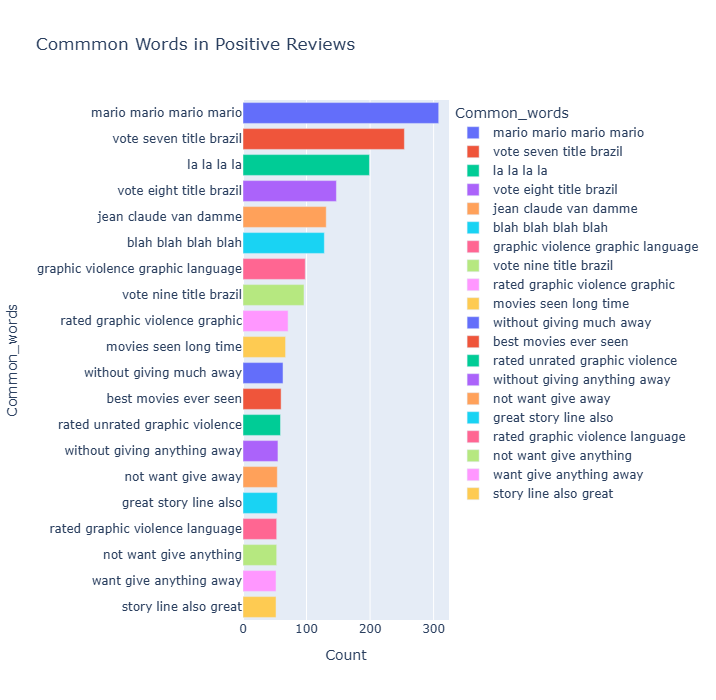

In [36]:
#Trigrams
# Assuming your cleaned data is in the 'Reviews' column
#Bigrams - Two words
from sklearn.feature_extraction.text import CountVectorizer
most_common_uni = get_top_text_ngrams(df['Reviews'][df['Ratings']>=7], 20, 4)

most_common_uni = dict(most_common_uni)
temp = pd.DataFrame(columns=["Common_words", 'Count'])
temp["Common_words"] = list(most_common_uni.keys())
temp["Count"] = list(most_common_uni.values())

fig = px.bar(
    temp, 
    x="Count", 
    y="Common_words", 
    title='Commmon Words in Positive Reviews', 
    orientation='h', 
    width=700, 
    height=700, 
    color='Common_words'
)
fig.show()

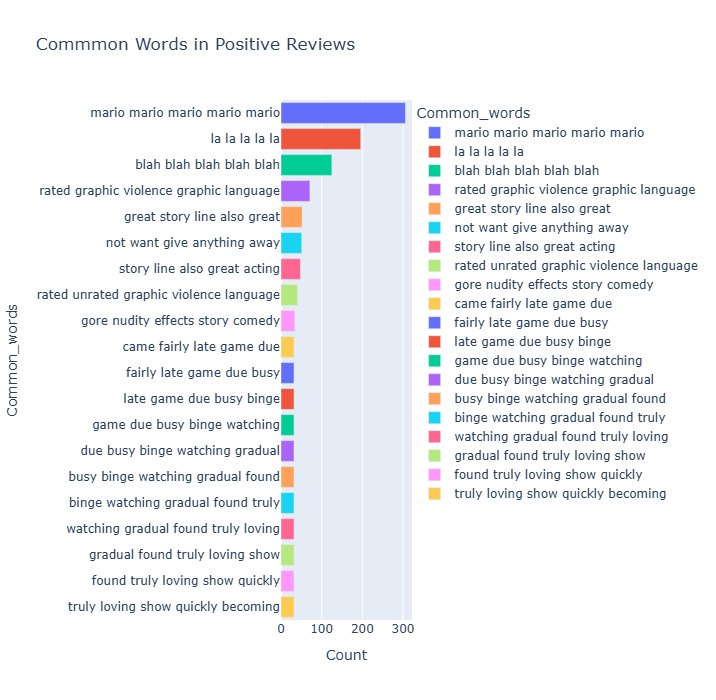

In [38]:
#Trigrams
# Assuming your cleaned data is in the 'Reviews' column
#Bigrams - Two words
from sklearn.feature_extraction.text import CountVectorizer
most_common_uni = get_top_text_ngrams(df['Reviews'][df['Ratings']>=7], 20, 5)

most_common_uni = dict(most_common_uni)
temp = pd.DataFrame(columns=["Common_words", 'Count'])
temp["Common_words"] = list(most_common_uni.keys())
temp["Count"] = list(most_common_uni.values())

fig = px.bar(
    temp, 
    x="Count", 
    y="Common_words", 
    title='Commmon Words in Positive Reviews', 
    orientation='h', 
    width=700, 
    height=700, 
    color='Common_words'
)
fig.show()

In [39]:
#In IMDB 150 -25-0 characters word is needed that's why people do this kind of things

pd.options.display.max_colwidth = 1000
df[["Reviews","Ratings","Movies"]][(df['Ratings']<=4)&(df['Reviews'].str.contains("blah blah blah| la la la la| mario mario mario mario"))].head(30)

,Reviews,Ratings,Movies
571,well not sure language made put babel fish typical line translated blah blah blah blah blah blah blah de actually makes sense lines actors uttering effects wise spotted left props voyage bottom sea think giant squids fish men best line cigar smoking middle aged man year old world become place boys like grow looks least god sake makes previous syfy effort savage planet alien killer bears look like masterpiece great going guys,1.0,War of the Worlds 2: The Next Wave
1070,not worst show even call internet not worry not kind guy bashes kids making videos usually actually good work done adults maybe voices different not watch videos immediately hate lucas infamous maker fred plays not care personal life anything want need tell got subscribed tube months end not deserve badge not mind k actor let explain fred video nutshell blah blah blah blah blah g judy ha not funny blah blah blah pointless yelling wow look kevin blah blah blah mom comes home says something unfunny blah blah blah subscribe person wasted time gave partial deafness ears high pitching easily done audacity original audio replaced synced worst videos tube clear effort whatsoever thinks daily situations really cares acts crazy annoying well stupid high pitched voice guarantee regret watching videos nobody ever met likes fred word,1.0,Fred
1220,many people seem watching false misconception going impression connected popular universal remake mummy sequels spin offs not case nothing films shared cast crew common story elements not even common studio producing effort literally nothing films commonly referred mockbuster low budget studio specializing low budget productions attempts capitalize success much larger profitable studio films making look like films deceptive tactics like using similar titles similar advertisements poster designs etc please know creators way connected affiliated previous mummy way felt important get way mockbuster trend growing problem world home entertainment thanks companies like asylum specialize almost exclusively making rip mockbusters least past decade caused increasing amount confusion consumers fans also note another important fact mummy resurrected bad not able make sit start finish cheap lazily constructed filled flimsy scares ludicrous amounts padding dreadfully acted minute runtime yes mi...,1.0,The Mummy Resurrected
2838,zombie corny made sense also slow jokes hours long dialogue cut slow worst movies ever seen far mostly never read ratings decide bad not cases bad horribly stupid disgusting waist time past makeup horrible porno zombie acting worst ever seen year old better wow still disgusted horribly bad blah blah blah reminded old kid neighborhood making friends seriously bad maybe year olds better,1.0,Dead Life
3534,truly horrid maybe worth watching instant modern camp classic notice submit bad reviews site bad movies hobby sorts thinks learn bad movies good ones thuth every student thesis written battlefield earth not wonder thinking amazed many people incompetent get released defies comprehension budget well ok servicable better term actors outfit fail miseraby amazing ways sucks combines elements horrid employs characters not develop way not care even root act irrational excessively stupid ways purpose lengthening serving plot worst part idea boring abrasive time like repeatedly stabbed still place sleep awake not really care anything crawl beginning well constant screen wipes complete rip star wars hesitate even mention review worse yet script spends third playing things already know crawl aliens whatever took earth killed humans ones still live living mostly tribal cultures still subjected quite lot going told even started waste time like immediately cheese starts get thick get hero tm ri...,1.0,Battlefield Earth
3869,pretty much permanent fixture imdb bottom list lawnmower man beyond cyberspace not widely considered worst sequels ever made widely considered worst films ever made period second claim s

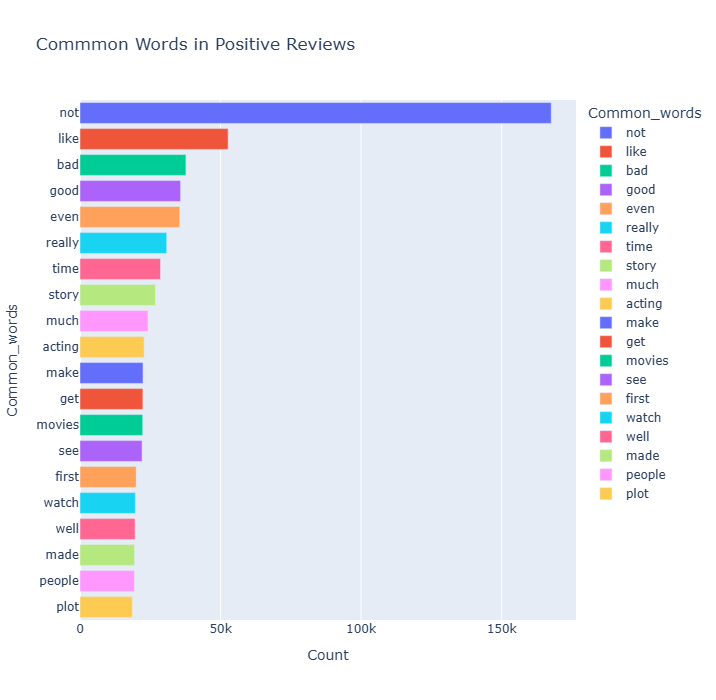

In [42]:
#Trigrams
# Assuming your cleaned data is in the 'Reviews' column
#Bigrams - Two words
from sklearn.feature_extraction.text import CountVectorizer
most_common_uni = get_top_text_ngrams(df['Reviews'][df['Ratings']<=4], 20, 1)

most_common_uni = dict(most_common_uni)
temp = pd.DataFrame(columns=["Common_words", 'Count'])
temp["Common_words"] = list(most_common_uni.keys())
temp["Count"] = list(most_common_uni.values())

fig = px.bar(
    temp, 
    x="Count", 
    y="Common_words", 
    title='Commmon Words in Positive Reviews', 
    orientation='h', 
    width=700, 
    height=700, 
    color='Common_words'
)
fig.show()

In [43]:
#Trigrams
# Assuming your cleaned data is in the 'Reviews' column
#Bigrams - Two words
from sklearn.feature_extraction.text import CountVectorizer
most_common_uni = get_top_text_ngrams(df['Reviews'][df['Ratings']<=4], 20, 2)

most_common_uni = dict(most_common_uni)
temp = pd.DataFrame(columns=["Common_words", 'Count'])
temp["Common_words"] = list(most_common_uni.keys())
temp["Count"] = list(most_common_uni.values())

fig = px.bar(
    temp, 
    x="Count", 
    y="Common_words", 
    title='Commmon Words in Positive Reviews', 
    orientation='h', 
    width=700, 
    height=700, 
    color='Common_words'
)
fig.show()

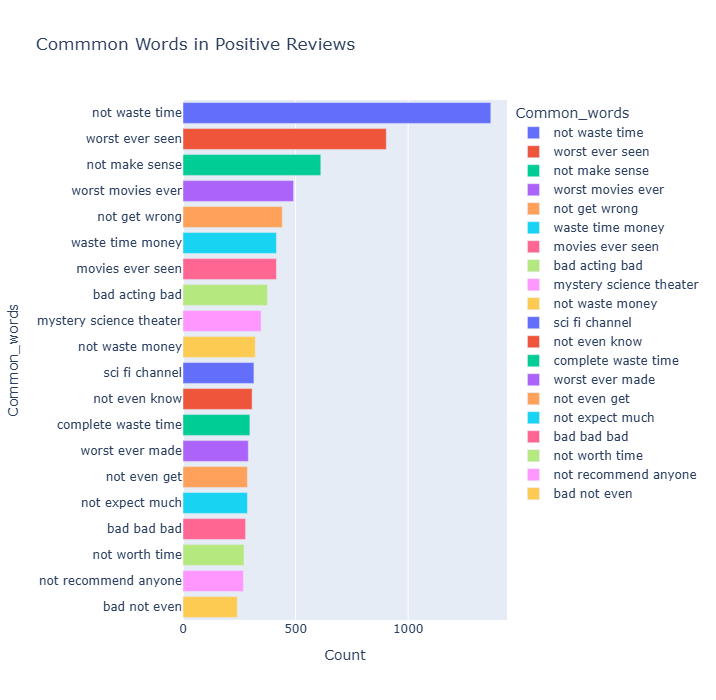

In [44]:
#Trigrams
# Assuming your cleaned data is in the 'Reviews' column
#Bigrams - Two words
from sklearn.feature_extraction.text import CountVectorizer
most_common_uni = get_top_text_ngrams(df['Reviews'][df['Ratings']<=4], 20, 3)

most_common_uni = dict(most_common_uni)
temp = pd.DataFrame(columns=["Common_words", 'Count'])
temp["Common_words"] = list(most_common_uni.keys())
temp["Count"] = list(most_common_uni.values())

fig = px.bar(
    temp, 
    x="Count", 
    y="Common_words", 
    title='Commmon Words in Positive Reviews', 
    orientation='h', 
    width=700, 
    height=700, 
    color='Common_words'
)
fig.show()

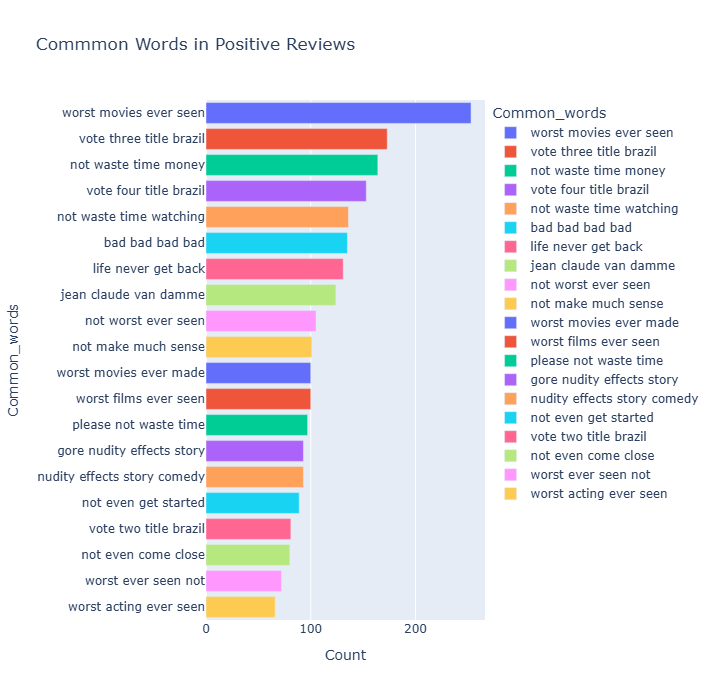

In [45]:
#Trigrams
# Assuming your cleaned data is in the 'Reviews' column
#Bigrams - Two words
from sklearn.feature_extraction.text import CountVectorizer
most_common_uni = get_top_text_ngrams(df['Reviews'][df['Ratings']<=4], 20, 4)

most_common_uni = dict(most_common_uni)
temp = pd.DataFrame(columns=["Common_words", 'Count'])
temp["Common_words"] = list(most_common_uni.keys())
temp["Count"] = list(most_common_uni.values())

fig = px.bar(
    temp, 
    x="Count", 
    y="Common_words", 
    title='Commmon Words in Positive Reviews', 
    orientation='h', 
    width=700, 
    height=700, 
    color='Common_words'
)
fig.show()

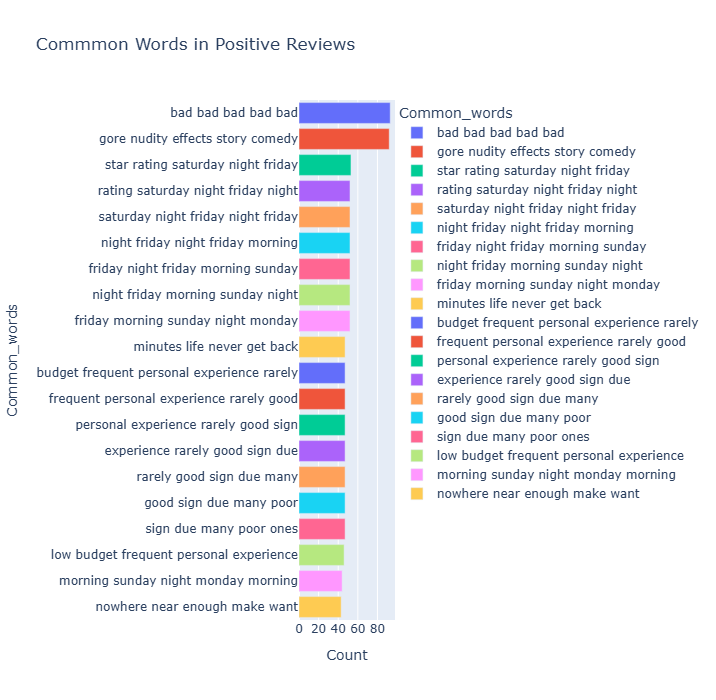

In [46]:
#Trigrams
# Assuming your cleaned data is in the 'Reviews' column
#Bigrams - Two words
from sklearn.feature_extraction.text import CountVectorizer
most_common_uni = get_top_text_ngrams(df['Reviews'][df['Ratings']<=4], 20, 5)

most_common_uni = dict(most_common_uni)
temp = pd.DataFrame(columns=["Common_words", 'Count'])
temp["Common_words"] = list(most_common_uni.keys())
temp["Count"] = list(most_common_uni.values())

fig = px.bar(
    temp, 
    x="Count", 
    y="Common_words", 
    title='Commmon Words in Positive Reviews', 
    orientation='h', 
    width=700, 
    height=700, 
    color='Common_words'
)
fig.show()

In [48]:
#In IMDB 150 -25-0 characters word is needed that's why people do this kind of things

pd.options.display.max_colwidth = 1000 
df[["Reviews","Ratings","Movies"]][(df['Ratings']<=4)&(df['Reviews'].str.contains("good|great"))].head(100)

,Reviews,Ratings,Movies
3,saw previous spoof movies two horrible gentlemen know already bad tell truth want watch brainless person ironically meant stereotypical teenagers not laugh bit judge even little automatically fails never ask comes two men remember good old hollywood days whenever making showing people type art also story kept edge seat well whenever word hit making films earned loads cash greedy people came picture quite pathetic two exception still artists notably genius christopher nolan two guys well writing big words let put simple terms guys guys suck not artists instead money craving whores latest proves even fails easily mind blowing mean nothing funny trailer people usually put best stuff like idiots sometimes knew going bad made bet friends not good idea write reviews paper tell everyone whats good whats bad friends flipped review well warning least not even called nothing artistic original jokes sorry references made throughout pretty much random like hannah montana juno gig actually clos...,1.0,Disaster Movie
6,given free ticket not complain ripped except minutes life irretrievably stolen sort movies date epic meet spartans not funny time disaster reached new low not real laugh anywhere alleged jokes actually painful considerable amount childish mean spirited stuff form racist sexist especially homophobic garbage present along ample helpings juvenile gross outs none actors even bothering put pretense acting nothing hip clever even mildly intelligent going entire beginning end crass vulgar irrational utterly humorless human sense know past sort trash made enough money keep seltzer et al grinding disaster may downfall franchise utter contempt seltzer collaborators audience finally beginning show clearly fails saw almost empty theater good chance seltzer go back drawing board stop making lazy catastrophes finally develop real sense humor unfunny piece puke stay away,1.0,Disaster Movie
7,ok disastrous not imaginative barb not shred wit saw free friend said pissed pants trailer free passes think incontinent spoof disaster movies fun not couple disaster movies get referenced not really spoofed instead spoofing recent movies genres aspects current pop culture current women wrestling head commercials anything good minute running time get minutes nicole parker seems like good good material,1.0,Disaster Movie
11,decided go see friends laugh hoping bad become funny awful cant take kid seriously also confirmed knew jb ego even bigger kayne west entire like look talented singer good person simply nothing not forgot mention mommies fat cigar smoking managers made jb puppet make look better buried deeper starting think done purpose fat cats want get rid not recommend,1.0,Justin Bieber: Never Say Never
12,right everyone imdb pretty much committed giving call get bottom list trust right went see knew way criticize without seeing however lacks artistic merit whatsoever full latest greatest pop sensations youtube generation names flashy lights stuffing cooked turkey show heart presentation message never give dreams however whole bieber smiling looking pretty grooming lesbian hair mentioned previous reviews theater full tween girls screaming heads every time inhaled exhaled someone really needs teach modern generation cinema etiquette least tell shut seconds honestly not know trying besides earn money add accolades stars names short pointless also sucks,1.0,Justin Bieber: Never Say Never
...,...,...,...
238,remember young child acquainted internet learning lawrence kasanoff foodfight seemed unlike anything ever heard combining dozens popular advertising mascots mr clean chester cheetah mrs buttersworth charlie tuna resemble toy story setting transferred supermarket story actually cinema animation baffling stories time development hell still captivates whenever scour internet looking summation exactly went picture story incredible ambition controversy unfathomably disappointing conclusion not familiar backstory give little rund

In [49]:
#In IMDB 150 -25-0 characters word is needed that's why people do this kind of things

pd.options.display.max_colwidth = 1000 
df[["Reviews","Ratings","Movies"]][(df['Ratings']<=4)&(df['Reviews'].str.contains("saturday night "))].head(100)

,Reviews,Ratings,Movies
491,presuming everyone reading seen awesome terrible time birdemic simple review pretty much tries emulate lot similar beats slow build opening tracking shot strutting think saturday night fever lot hollywood locations attempting show step gives us first areally moment badly blurred advert not cut shot final print although leads first return another blonde dork romance cruise ship reject returns musical interlude people use coat hangers defence find yet firearms not mention lots favourite element shouting big numbers give thousand dollars give million dollars fund typical hollywood costs hundred million dollars get little exposition catch people survived time tries go meta reeling films director likes telling us directors not final say actresses struggle actors died young etc come bit early undermining uneven sound jumpy cameras bad editing poor script still showing us director learnt nothing people start repeating giant jumbo jellyfish get flashback eagles attacking cavemen not help t...,1.0,Birdemic 2: The Resurrection
910,heard never intention watching day video store browsing art dvds shining price tag screaming suck buy figure hell huge wrestling fan not bad right get home put disc lay watch less three minutes later realize way hell watch thing alone coming man sat practically every blaxploitation ever made somehow managed convince friends spend saturday night watching poorly made straight video backyard wrestling instead going fun like normal people decision come regret bad mean bad backyard dogs awful consult thesaurus order properly describe abominable atrocious fallacious sinful horrendous not know anyone involved live deserve shunned society live rest lives shame seen better movies work safety training backyard dogs bad think qualify obscenity rating billion,1.0,Backyard Dogs
1126,hate biker nothing blatant ripoff easy rider sure biker babes not hot evil bikers heck angels place angels acting cheesy story made sense plot many continuity errors tell got worst biker known man watch watch peter fonda easy rider risqu saturday night fever story rocks babes hotter angels really devils much not watch mystery science theater similar wild rebels glad stinks like dirty diaper lol indeed,1.0,The Hellcats
1139,good things negatives overwhelming give ole scale cinematography pretty miniature set models excellent least think models everything bogus may actually real locations directors yes took two directors cook turkey somehow managed make look like models two directors think half bad instead doubly pretentious lovely denise boutte may well hammiest actor planet earth rhett giles van helsing looks like reject pet shop boys acting nearly overblown stuffy ms boutte every line every actor recited emo overdrive also least two writers involved version saw three listed unless hallucinating imdb says two third may requested anonymity hacked webpage erased name case dialog cheesy think written teen gothtards saturday night live see pseudo goth vampire semi clad model pretty airheads melting arms ralph lauren pretty men ersatz populated nightclubs puke kidney anne rice apparently spawned sub race cretinous filmmakers first seen challenges uwe boll house dead worst horror ever made,1.0,Way of the Vampire
1353,first saw summer knew hit bottom imdb least bad crap guys forced watch totally forgot digging box old tapes wish remembered come warn everyone back consists really bad blair witch parodies separated fake commercials make worst saturday night live skit seem like high art example guy dressed bigfoot sitting desk waves arms around growls goes next segment yes actually put parodies seem like something students decided weekend show friends drinking party like watching someone bad home videos not string together call oh forgot pauly shore thought maybe done full parody tbwp made least little funny since experience comedy minutes middle not funny least redeeming qualities,1.0,The Bogus Witch Project
...,...,...,...
2